Read train.csv and test.csv.

In [63]:
import pandas as pd

train_df = pd.read_csv('train.csv')
x_train = train_df['Article']
y_train = train_df['Category']

test_df = pd.read_csv('test.csv')
x_test = test_df['Article']
y_test = test_df['Category']

Select the 10,000 most essential words.

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000)
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

I chose k=12 and Euclidean distance to train my kNN. When drawing the decision boundary, I didn't directly select two words (features) but instead chose to use dimension reduction (DR) techniques (TruncatedSVD). This is because the text data has 10,000 dimensions after TF-IDF transformation, and the sparse word frequencies of individual words are extremely isolated. If only two words are selected, it will be completely unable to represent the global semantics, and the drawn boundary will be completely unrepresentative.

(i) Distance Metrics

Manhattan Distance: Calculates distance along axis, resulting in jagged boundaries.

Euclidean Distance: Calculates straight-line distance, resulting in smoother, more curved boundaries.

(2) k-Value

k too small: Overfitting.

k too large: Underfitting.

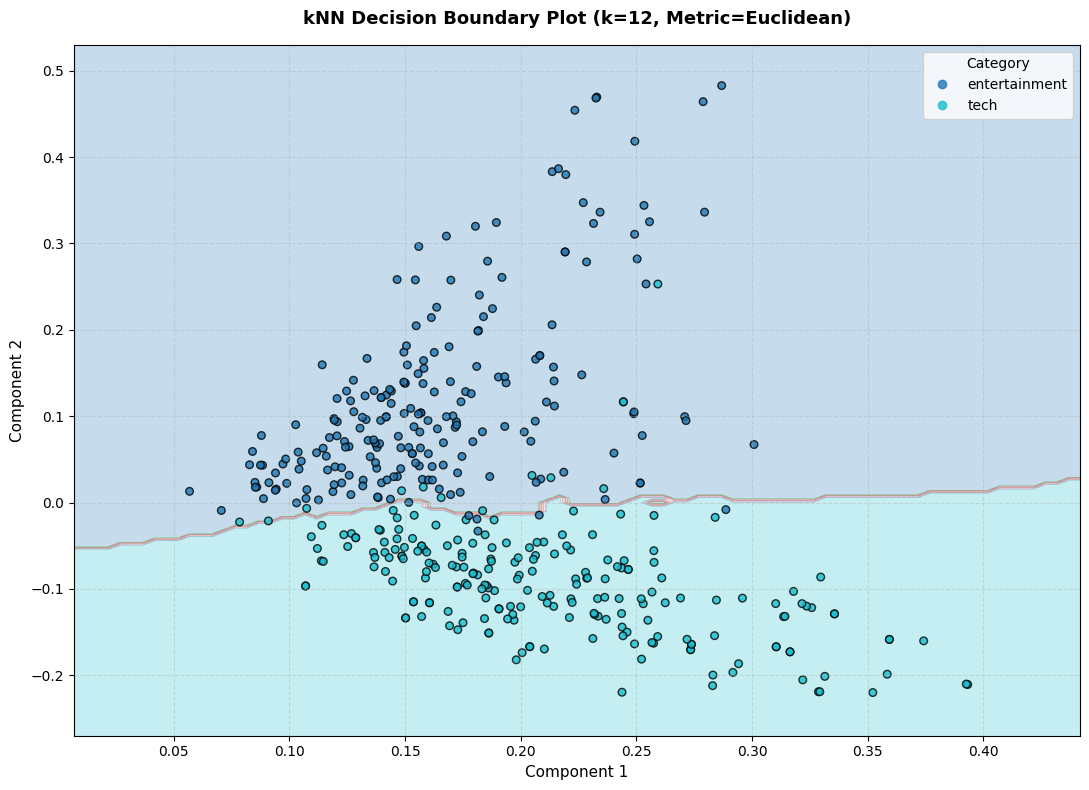

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

svd = TruncatedSVD(n_components=2, random_state=42)
x_train_2d = svd.fit_transform(x_train_tfidf)
le = LabelEncoder()
y_train_2d = le.fit_transform(y_train)

knn_boundary_model = KNeighborsClassifier(n_neighbors=12, metric='euclidean')
knn_boundary_model.fit(x_train_2d, y_train_2d)

x_min, x_max = x_train_2d[:, 0].min() - 0.05, x_train_2d[:, 0].max() + 0.05
y_min, y_max = x_train_2d[:, 1].min() - 0.05, x_train_2d[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.005),
                     np.arange(y_min, y_max, 0.005))

Z = knn_boundary_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(11, 8))
plt.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.tab10)
scatter = plt.scatter(x_train_2d[:, 0], x_train_2d[:, 1], c=y_train_2d, 
                      cmap=plt.cm.tab10, edgecolors='k', s=30, alpha=0.8)
plt.title(f"kNN Decision Boundary Plot (k={12}, Metric={'euclidean'.capitalize()})", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Component 1", fontsize=11)
plt.ylabel("Component 2", fontsize=11)
plt.legend(handles=scatter.legend_elements()[0], labels=list(le.classes_), loc='best', title="Category")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

 I used 5-fold cross-validation on the training set to find the best hyperparameters, and k=10 and 12 turned out to be the best. Since I did all the CV within train.csv, I didn't break the 'golden rule' — meaning I didn't cheat by peeking at the test data.

In [66]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

k_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
euclidean_f1_scores = []

for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')  
    scores = cross_val_score(knn, x_train_tfidf, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    euclidean_f1_scores.append(np.mean(scores))

f1_table = pd.DataFrame({
    'K_Neighbors': k_list,
    'Euclidean_Macro_F1': euclidean_f1_scores
})
print(f1_table.to_string(index=False, formatters={'Euclidean_Macro_F1': '{:.5f}'.format}))

 K_Neighbors Euclidean_Macro_F1
           1            0.94624
           2            0.94628
           3            0.95798
           4            0.97201
           5            0.96968
           6            0.97204
           7            0.96968
           8            0.97665
           9            0.97434
          10            0.97900
          11            0.97434
          12            0.97900
          13            0.97433
          14            0.97434
          15            0.96965


The accuracy of kNN with the best hyperparameter settings in 𝐹1 measure on the testing dataset is 0.98069.

In [67]:
from sklearn.metrics import f1_score

final_knn = KNeighborsClassifier(n_neighbors=12, metric='euclidean')
final_knn.fit(x_train_tfidf, y_train)
y_test_pred = final_knn.predict(x_test_tfidf)

final_macro_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"Final Macro F1-Score on Test Set: {final_macro_f1:.5f}")


Final Macro F1-Score on Test Set: 0.98069


Explore how the size of the training data set affects the test and train accuracy of kNN classifiers with the best hyperparameter settings.

In [68]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

N = x_train.shape[0]
m_values = [0.1, 0.3, 0.5, 0.7, 0.9]
knn_train_f1 = []
knn_test_f1 = []
best_knn = KNeighborsClassifier(n_neighbors=12, metric='euclidean')

for m in m_values:
    end_idx = int(m * N)
    x_train_m = x_train_tfidf[0:end_idx]
    y_train_m = y_train[0:end_idx]
    
    best_knn.fit(x_train_m, y_train_m)

    y_train_pred = best_knn.predict(x_train_m)
    train_f1 = f1_score(y_train_m, y_train_pred, average='macro')
    knn_train_f1.append(train_f1)
    
    y_test_pred = best_knn.predict(x_test_tfidf)
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    knn_test_f1.append(test_f1)
    
    print(f" m = {m}  (train_samples: {end_idx}): Train F1 = {train_f1:.4f}, Test F1 = {test_f1:.4f}")

 m = 0.1  (train_samples: 42): Train F1 = 0.8963, Test F1 = 0.9429
 m = 0.3  (train_samples: 128): Train F1 = 0.9765, Test F1 = 0.9807
 m = 0.5  (train_samples: 214): Train F1 = 0.9813, Test F1 = 0.9711
 m = 0.7  (train_samples: 299): Train F1 = 0.9765, Test F1 = 0.9711
 m = 0.9  (train_samples: 385): Train F1 = 0.9818, Test F1 = 0.9807


Two plots

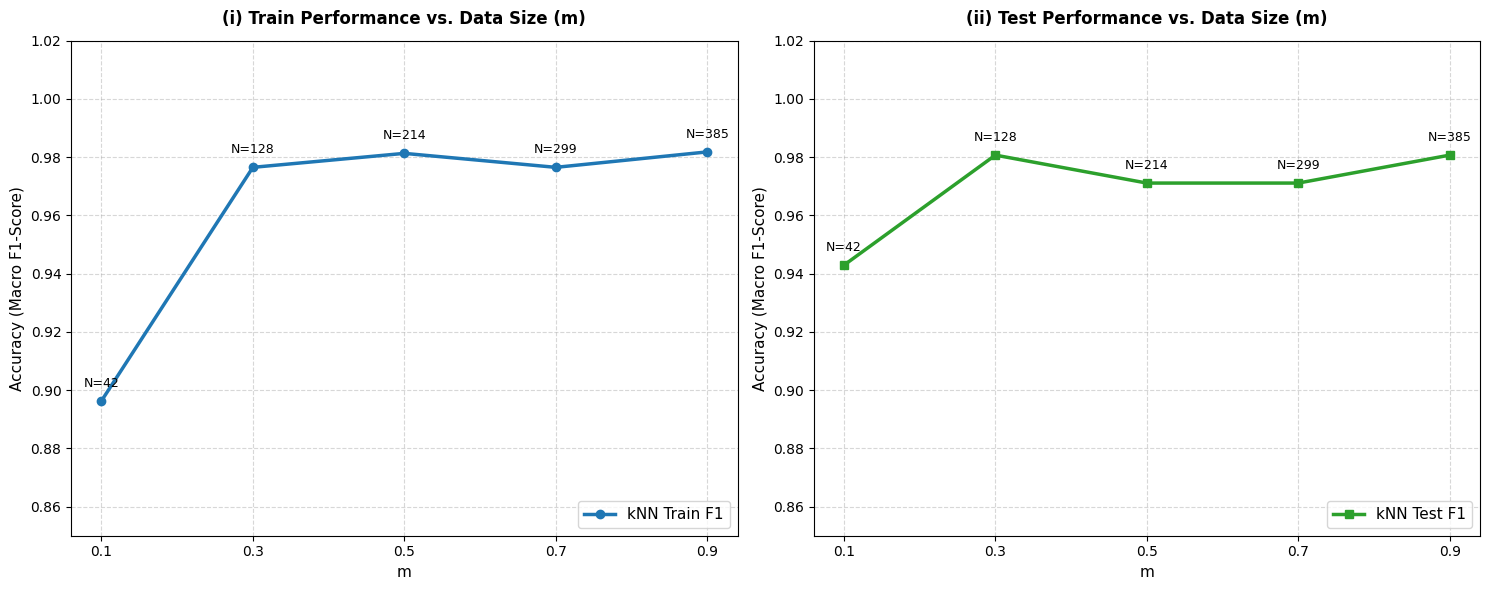

In [69]:
import matplotlib.pyplot as plt

m_values = [0.1, 0.3, 0.5, 0.7, 0.9]
train_samples = [42, 128, 214, 299, 385]
train_f1_scores = [0.8963, 0.9765, 0.9813, 0.9765, 0.9818]
test_f1_scores = [0.9429, 0.9807, 0.9711, 0.9711, 0.9807]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(m_values, train_f1_scores, marker='o', linewidth=2.5, color='#1f77b4', label='kNN Train F1')
for i, txt in enumerate(train_samples):
    ax1.annotate(f'N={txt}', (m_values[i], train_f1_scores[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
ax1.set_title('(i) Train Performance vs. Data Size (m)', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('m', fontsize=11)
ax1.set_ylabel('Accuracy (Macro F1-Score)', fontsize=11)
ax1.set_xticks(m_values)
ax1.set_ylim(0.85, 1.02)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower right', fontsize=11)


ax2.plot(m_values, test_f1_scores, marker='s', linewidth=2.5, color='#2ca02c', label='kNN Test F1')
for i, txt in enumerate(train_samples):
    ax2.annotate(f'N={txt}', (m_values[i], test_f1_scores[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
ax2.set_title('(ii) Test Performance vs. Data Size (m)', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('m', fontsize=11)
ax2.set_ylabel('Accuracy (Macro F1-Score)', fontsize=11)
ax2.set_xticks(m_values)
ax2.set_ylim(0.85, 1.02)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()